# Irreversible Regime Transitions

## Overview
- **Goal**: Simulate and detect irreversible regime transitions
- **Key Idea**: some transitions change the rules permanently

## Model
- There is a hidden "true pressure" state $x_{\text{t}}$ that we can't observe directly
- A latent failure gate  $s_t \in \{0,1\}$ is irreversible once $s_t = 1$, it never goes back to 0.
- The probability of switching to failure increases as degradation $d_t$ grows.
- When failed, pressure behavior changes (bias shift and/or increased volstility).
- Simulate data, then run two monitore:
    - standard innovation (pressure residual surprise)
    - rolling $|z|$-energy (shock/volatility bursts)
  
- Drift/noise depend on regime
- **transition rules**: 0→1 only

## Detection
- innovation $z_{\text{t}}$
- pressure energy = rolling mean($|z|$)
- pressure event = sustained elevation
- transition event = one-way regime update

## Degradation Ramp
$$
d_t = d_{t-1} + r + \eta_t \quad
\text{where} \quad
\eta_t \sim \mathcal{N}(0, \sigma_d^2), \quad d_0 = 0
$$

## Logistic Failure Probability
$$
p_t = /frac{1}{1 + e^{-\alpha(d_t - d^\*)}}
$$

## Irreversible Gate
$$
s_t =
\begin{cases}
1 & \text{if } s_{t-1} = 1 \\
\text{Bernoulli}(p_t) & \text{if } s_{t-1} = 0
\end{cases}
$$

## Dynamics
$$
x_t = x_{t-1} + w_t, \quad
w_t \sim \mathcal{N}(0, q_0)
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
np.random.seed(7)

T = 300
x0 = 0.0

r_meas = 1.0
q0 = 0.05
q1 = 0.40
b = -0.08

ramp_r = 0.01
sigma_d = 0.005
alpha = 10.0
d_star = 1.5

In [18]:
d = np.zeros(T)
s = np.zeros(T)
x = np.zeros(T)
y = np.zeros(T)

x[0] = x0
change_t = None

for t in range(1, T):
    d[t] = d[t-1] + ramp_r + np.random.normal(0.0, sigma_d)

    p = 1.0 / (1.0 + np.exp(-alpha * (d[t] - d_star)))

    if s[t-1] == 1:
        s[t] = 1
    else:
        s[t] = 1 if (np.random.rand() < p) else 0
        if (s[t] == 1) and (change_t is None):
            change_t = t

In [22]:
for t in range(1, T):
    q = q1 if s[t] ==1 else q0
    drift = b if s[t] == 1 else 0.0
    x[t] = x[t-1] + drift + np.random.normal(0.0, np.sqrt(q))
    y[t] = x[t] + np.random.normal(0.0, np.sqrt(r_meas))

change_t, d[-1], s.sum()

(123, np.float64(2.900603707419242), np.float64(177.0))

In [27]:
# Kalman one-step predction & standardized innovation z_t

z = np.zeros(T)
S = np.zeros(T)

m = y[0]    # state mean estimate
P = 1.0     # state variance estimate 

for t in range (1, T):
    # random walk
    m_pred = m
    P_pred = P + q0

    # innovation
    e = y[t] - m_pred
    S_t = P_pred + r_meas
    z[t] = e / np.sqrt(S_t)

    # update
    K = P_pred / S_t
    m = m_pred + K * e
    P = (1.0 - K) * P_pred





In [28]:
# rolling |z| energy - shocks

W = 20
energy = np.full(T, np.nan)

for t in range(W, T):
    window = z[t-W+1: t+1]
    energy[t] = np.mean(np.abs(window)) # simple |z| energy

In [29]:
# pressure & shock flags

z_thr = 3.0
e_thr = 1.5

pressure_flag = (np.abs(z) > z_thr)
shock_flag = (energy > e_thr)

int(np.sum(pressure_flag)), int(np.nansum(shock_flag))


(8, 29)

Text(0.5, 1.0, 'Standardized innovation z_t')

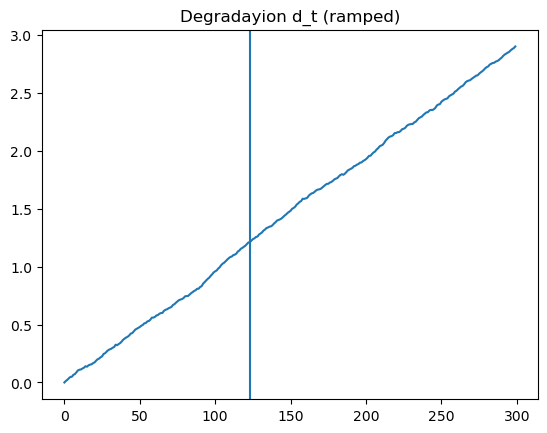

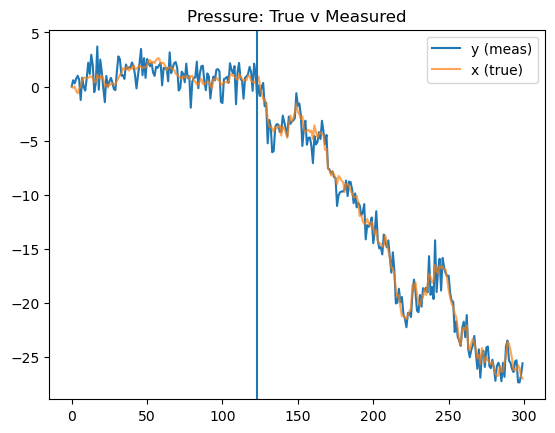

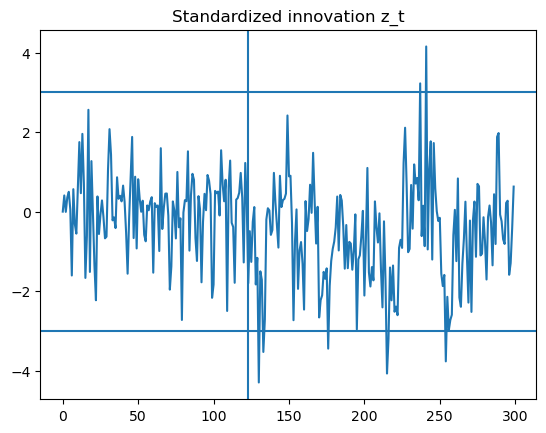

In [39]:
# diagnostic plots

t = np.arange(T)

plt.figure()
plt.plot(t, d)
if change_t is not None: plt.axvline(change_t)
plt.title('Degradayion d_t (ramped)')


plt.figure()
plt.plot(t, y, label='y (meas)')
plt.plot(t, x, label='x (true)', alpha=0.7)
if change_t is not None: plt.axvline(change_t)
plt.legend()
plt.title('Pressure: True v Measured')

plt.figure()
plt.plot(t, z)
plt.axhline(z_thr); plt.axhline(-z_thr)
if change_t is not None: plt.axvline(change_t)
plt.title('Standardized innovation z_t')

Text(0.5, 1.0, 'Rolling |z| energy (shock monitor)')

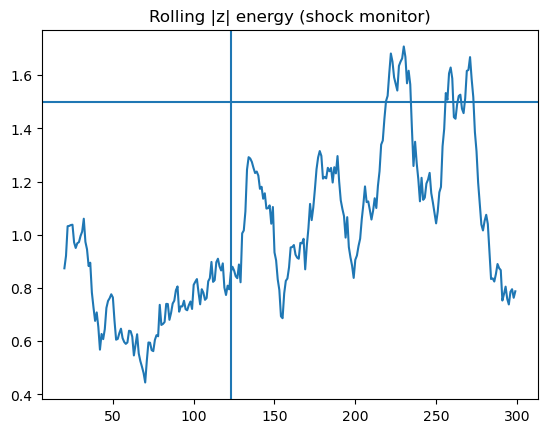

In [38]:
plt.figure()
plt.plot(t, energy)
plt.axhline(e_thr)
if change_t is not None: plt.axvline(change_t)
plt.title('Rolling |z| energy (shock monitor)')

# Interpretation
- **Degradation $d_t$** increases with a steady positive slope and crosses the critical region near $d^\*$. The transition does not occur because of a sudden jump in degradation — it occurs because the accumulated ramp pushes failure probability through a nonlinear threshold.
- **Standardized innovation $z_t$** shows a sharp negative spike at the transition. This reflects model mismatch: the healthy-state Kalman filter cannot explain the sudden drift change, so residual surprise increases abruptly.
- **Rolling $|z|$- energy** transitions from compressed, low-variance behavior to a sustained high-amplitude regime. This indicates that the failure is not a one-time shock, but a persistent change in system dynamics.